# Exploratory Cultural-Distance Analysis

This post-hoc analysis tests whether the Phase 2 cultural-identity prompt
improvement (`P1 − P0`) increased with a country-level proxy for cultural
distance.

The analysis is exploratory, not causal. Country distance is an imperfect
proxy for language communities, the primary sample contains eight non-English
languages, and three observations share Nigeria as their country proxy.


> **Analysis boundary:** This analysis is post-hoc and exploratory. Cultural distance is approximated using country-level proxy measures rather than speaker-community-level cultural measures. The results are used to test whether there is visible evidence of a distance-gain relationship, not to prove cultural causation.

## Methodological decisions

- Outcome: canonical Phase 2 `P1 macro-F1 − P0 macro-F1`.
- Distance source: Facebook cosine cultural distance from Obradovich et al.
  (2022).
- Primary anchor: mean distance to the United Kingdom and United States.
- Primary test: Spearman correlation with an exact two-sided permutation test.
- Uncertainty: 10,000 percentile bootstrap resamples, seed 42.
- Robustness: UK-only, US-only, country aggregation, English inclusion and
  leave-one-country-out analyses.


## 1. Environment and corrected Drive paths


In [ ]:
import itertools
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from google.colab import drive
drive.mount("/content/drive", force_remount=False)

PROJECT_DIR = Path("/content/drive/MyDrive/EmotionDetection")
CHECKPOINT_DIR = PROJECT_DIR / "CAST_checkpoints"
PHASE2_RESULTS_PATH = Path(
    "/content/drive/MyDrive/EmotionDetection/CAST_checkpoints/Phase2/phase2_validation_raw_results_gemma4.json"
)

CULTURAL_DISTANCE_DIR = CHECKPOINT_DIR / "CulturalDistance"
METADATA_DIR = CULTURAL_DISTANCE_DIR / "metadata"
RESULTS_DIR = CULTURAL_DISTANCE_DIR / "results"
FIGURES_DIR = CULTURAL_DISTANCE_DIR / "figures"
DISTANCE_MATRIX_PATH = Path(
    "/content/drive/MyDrive/EmotionDetection/CAST_checkpoints/CulturalDistance/metadata/FBCosDist.csv"
)

for directory in [
    CULTURAL_DISTANCE_DIR,
    METADATA_DIR,
    RESULTS_DIR,
    FIGURES_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

required_inputs = [
    PHASE2_RESULTS_PATH,
    DISTANCE_MATRIX_PATH,
]
missing_inputs = [
    path for path in required_inputs
    if not path.exists()
]
if missing_inputs:
    raise FileNotFoundError(
        "Required cultural-distance inputs are missing:\n"
        + "\n".join(f"  - {path}" for path in missing_inputs)
    )

print("Phase 2 results:", PHASE2_RESULTS_PATH)
print("Distance matrix:", DISTANCE_MATRIX_PATH)
print("Output directory:", CULTURAL_DISTANCE_DIR)


Mounted at /content/drive
Phase 2 results: /content/drive/MyDrive/EmotionDetection/CAST_checkpoints/Phase2/phase2_validation_raw_results_gemma4.json
Distance matrix: /content/drive/MyDrive/EmotionDetection/CAST_checkpoints/CulturalDistance/metadata/FBCosDist.csv
Output directory: /content/drive/MyDrive/EmotionDetection/CAST_checkpoints/CulturalDistance


## 2. Country-proxy mapping


In [ ]:
SEED = 42
N_BOOT = 10_000

DISTANCE_SOURCE_URL = (
    "https://measuring-culture.github.io/"
    "Expanding-Measurement-Culture-Facebook-JRSI/"
)
DISTANCE_PAPER_DOI = "https://doi.org/10.1098/rsif.2022.0085"

LANGUAGE_MAPPING = {
    "ENG": {
        "language": "English",
        "country": "United Kingdom",
        "iso2": "GB",
        "mapping_note": (
            "Used only in a sensitivity analysis. English is excluded from "
            "the primary analysis because the dataset language does not "
            "represent one uniquely defined national culture."
        ),
    },
    "HIN": {
        "language": "Hindi",
        "country": "India",
        "iso2": "IN",
        "mapping_note": "Country-level proxy for the language community.",
    },
    "RUS": {
        "language": "Russian",
        "country": "Russia",
        "iso2": "RU",
        "mapping_note": "Country-level proxy for the language community.",
    },
    "HAU": {
        "language": "Hausa",
        "country": "Nigeria",
        "iso2": "NG",
        "mapping_note": (
            "Nigeria is used as a proxy; Hausa is spoken across several "
            "countries."
        ),
    },
    "KIN": {
        "language": "Kinyarwanda",
        "country": "Rwanda",
        "iso2": "RW",
        "mapping_note": "Country-level proxy for the language community.",
    },
    "SUN": {
        "language": "Sundanese",
        "country": "Indonesia",
        "iso2": "ID",
        "mapping_note": "Country-level proxy for the language community.",
    },
    "YOR": {
        "language": "Yoruba",
        "country": "Nigeria",
        "iso2": "NG",
        "mapping_note": (
            "Nigeria is used as a proxy; Yoruba is spoken across several "
            "countries."
        ),
    },
    "VMW": {
        "language": "Emakhuwa",
        "country": "Mozambique",
        "iso2": "MZ",
        "mapping_note": "Country-level proxy for the language community.",
    },
    "PCM": {
        "language": "Nigerian Pidgin",
        "country": "Nigeria",
        "iso2": "NG",
        "mapping_note": "Nigeria is used as the country-level proxy.",
    },
}


## 3. Statistical helper functions


In [ ]:
def rank_average(values: np.ndarray) -> np.ndarray:
    return pd.Series(values).rank(method="average").to_numpy(dtype=float)


def spearman_rho(x: np.ndarray, y: np.ndarray) -> float:
    xr = rank_average(np.asarray(x, dtype=float))
    yr = rank_average(np.asarray(y, dtype=float))
    xc = xr - xr.mean()
    yc = yr - yr.mean()
    denominator = np.sqrt(np.dot(xc, xc) * np.dot(yc, yc))
    if denominator == 0:
        return np.nan
    return float(np.dot(xc, yc) / denominator)


def exact_permutation_p_two_sided(
    x: np.ndarray, y: np.ndarray
) -> tuple[float, float, int]:
    """Exact randomisation p-value for Spearman's rho.

    The outcome ranks are permuted over the fixed cultural-distance ranks. This
    is feasible here because the largest analysis contains only nine rows.
    """

    xr = rank_average(np.asarray(x, dtype=float))
    yr = rank_average(np.asarray(y, dtype=float))
    xc = xr - xr.mean()
    yc = yr - yr.mean()
    denominator = np.sqrt(np.dot(xc, xc) * np.dot(yc, yc))
    observed = float(np.dot(xc, yc) / denominator)

    permutations = np.asarray(
        list(itertools.permutations(yr)), dtype=float
    )
    permutation_rhos = (
        (permutations - yr.mean()) @ xc / denominator
    )
    p_value = float(
        np.mean(
            np.abs(permutation_rhos)
            >= abs(observed) - 1e-12
        )
    )
    return observed, p_value, len(permutations)


def bootstrap_spearman_ci(
    x: np.ndarray,
    y: np.ndarray,
    *,
    n_boot: int = N_BOOT,
    seed: int = SEED,
) -> tuple[float, float, int]:
    rng = np.random.default_rng(seed)
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    n = len(x)
    estimates: list[float] = []

    for _ in range(n_boot):
        index = rng.integers(0, n, n)
        estimate = spearman_rho(x[index], y[index])
        if np.isfinite(estimate):
            estimates.append(estimate)

    if not estimates:
        return np.nan, np.nan, 0

    low, high = np.percentile(estimates, [2.5, 97.5])
    return float(low), float(high), len(estimates)


def build_distance_lookup(
    distance_frame: pd.DataFrame,
) -> dict[tuple[str, str], float]:
    required = {"ISO_CODE_1", "ISO_CODE_2", "FBDist"}
    missing = required - set(distance_frame.columns)
    if missing:
        raise ValueError(
            f"Distance matrix missing columns: {sorted(missing)}"
        )

    return {
        (str(row.ISO_CODE_1), str(row.ISO_CODE_2)): float(
            row.FBDist
        )
        for row in distance_frame.itertuples(index=False)
    }


def get_distance(
    lookup: dict[tuple[str, str], float],
    first: str,
    second: str,
) -> float:
    value = lookup.get((first, second))
    if value is None:
        value = lookup.get((second, first))
    if value is None:
        raise KeyError(
            f"No cultural distance for {first}-{second}"
        )
    return float(value)


def run_test(
    frame: pd.DataFrame,
    *,
    test_id: str,
    level: str,
    population: str,
    distance_column: str,
    anchor: str,
    notes: str,
) -> dict[str, object]:
    x = frame[distance_column].to_numpy(dtype=float)
    y = frame["p1_minus_p0"].to_numpy(dtype=float)
    rho, p_value, permutations = exact_permutation_p_two_sided(
        x, y
    )
    ci_low, ci_high, valid_bootstraps = bootstrap_spearman_ci(
        x, y
    )

    if p_value < 0.05 and rho > 0:
        interpretation = (
            "Positive association; exploratory evidence is consistent "
            "with larger gains at greater distance."
        )
    elif p_value < 0.05 and rho < 0:
        interpretation = (
            "Negative association; exploratory evidence runs opposite "
            "to the proposed direction."
        )
    else:
        interpretation = (
            "No statistically reliable association in this exploratory "
            "sample."
        )

    return {
        "test_id": test_id,
        "level": level,
        "population": population,
        "distance_measure": distance_column,
        "anchor": anchor,
        "n": len(frame),
        "spearman_rho": round(rho, 6),
        "exact_permutation_p_two_sided": round(p_value, 6),
        "permutations": permutations,
        "bootstrap_ci_low": round(ci_low, 6),
        "bootstrap_ci_high": round(ci_high, 6),
        "valid_bootstrap_samples": valid_bootstraps,
        "interpretation": interpretation,
        "notes": notes,
    }


## 4. Build the analysis data and run the tests


In [ ]:
with open(PHASE2_RESULTS_PATH, "r") as handle:
    phase2_results = json.load(handle)

distance_matrix = pd.read_csv(DISTANCE_MATRIX_PATH)
distance_lookup = build_distance_lookup(distance_matrix)

missing_languages = [
    code.lower()
    for code in LANGUAGE_MAPPING
    if code.lower() not in phase2_results
]
if missing_languages:
    raise ValueError(
        f"Phase 2 results missing languages: {missing_languages}"
    )

language_rows = []
for code, mapping in LANGUAGE_MAPPING.items():
    result = phase2_results[code.lower()]
    p0 = result.get("p0", {}).get("macro_f1")
    p1 = result.get("p1", {}).get("macro_f1")
    if p0 is None or p1 is None:
        raise ValueError(f"{code}: missing canonical P0 or P1 macro-F1")

    iso2 = mapping["iso2"]
    distance_to_uk = get_distance(distance_lookup, iso2, "GB")
    distance_to_us = get_distance(distance_lookup, iso2, "US")

    language_rows.append({
        "code": code,
        "language": mapping["language"],
        "country_proxy": mapping["country"],
        "iso2": iso2,
        "p0_macro_f1": float(p0),
        "p1_macro_f1": float(p1),
        "p1_minus_p0": round(float(p1 - p0), 4),
        "distance_to_uk": distance_to_uk,
        "distance_to_us": distance_to_us,
        "distance_anglophone_mean": (
            distance_to_uk + distance_to_us
        ) / 2,
        "included_primary": code != "ENG",
        "mapping_note": mapping["mapping_note"],
        "distance_source": DISTANCE_SOURCE_URL,
    })

language_analysis = pd.DataFrame(language_rows)
primary = language_analysis[
    language_analysis["included_primary"]
].copy()

country_analysis = (
    primary
    .groupby(["country_proxy", "iso2"], as_index=False)
    .agg(
        languages=("language", lambda values: ", ".join(values)),
        language_count=("language", "size"),
        p1_minus_p0=("p1_minus_p0", "mean"),
        distance_to_uk=("distance_to_uk", "first"),
        distance_to_us=("distance_to_us", "first"),
        distance_anglophone_mean=(
            "distance_anglophone_mean",
            "first",
        ),
    )
    .sort_values("country_proxy")
    .reset_index(drop=True)
)

tests = [
    run_test(
        primary,
        test_id="primary_language_anglophone_mean",
        level="language",
        population="Eight non-English target languages",
        distance_column="distance_anglophone_mean",
        anchor="Mean of United Kingdom and United States",
        notes=(
            "Primary exploratory test. English is excluded. Nigeria appears "
            "three times, so a country-aggregated sensitivity analysis is "
            "also reported."
        ),
    ),
    run_test(
        primary,
        test_id="sensitivity_language_uk",
        level="language",
        population="Eight non-English target languages",
        distance_column="distance_to_uk",
        anchor="United Kingdom",
        notes="Anchor sensitivity analysis.",
    ),
    run_test(
        primary,
        test_id="sensitivity_language_us",
        level="language",
        population="Eight non-English target languages",
        distance_column="distance_to_us",
        anchor="United States",
        notes="Anchor sensitivity analysis.",
    ),
    run_test(
        country_analysis,
        test_id="sensitivity_country_aggregated",
        level="country proxy",
        population="Six unique non-English country proxies",
        distance_column="distance_anglophone_mean",
        anchor="Mean of United Kingdom and United States",
        notes=(
            "The three Nigeria-linked languages are averaged into one "
            "Nigeria observation."
        ),
    ),
    run_test(
        language_analysis,
        test_id="sensitivity_include_english",
        level="language",
        population="All nine languages",
        distance_column="distance_anglophone_mean",
        anchor="Mean of United Kingdom and United States",
        notes=(
            "English is mapped to the United Kingdom only for this "
            "sensitivity analysis."
        ),
    ),
]
test_summary = pd.DataFrame(tests)

leave_one_out_rows = []
for country in country_analysis["country_proxy"]:
    subset = country_analysis[
        country_analysis["country_proxy"] != country
    ]
    rho = spearman_rho(
        subset["distance_anglophone_mean"].to_numpy(),
        subset["p1_minus_p0"].to_numpy(),
    )
    leave_one_out_rows.append({
        "omitted_country": country,
        "n_remaining": len(subset),
        "spearman_rho": round(rho, 6),
    })
leave_one_out = pd.DataFrame(leave_one_out_rows)

display(test_summary)


,test_id,level,population,distance_measure,anchor,n,spearman_rho,exact_permutation_p_two_sided,permutations,bootstrap_ci_low,bootstrap_ci_high,valid_bootstrap_samples,interpretation,notes
0,primary_language_anglophone_mean,language,Eight non-English target languages,distance_anglophone_mean,Mean of United Kingdom and United States,8,0.146385,0.743155,40320,-0.679558,0.871306,9994,No statistically reliable association in this ...,Primary exploratory test. English is excluded....
1,sensitivity_language_uk,language,Eight non-English target languages,distance_to_uk,United Kingdom,8,0.146385,0.743155,40320,-0.679558,0.871306,9994,No statistically reliable association in this ...,Anchor sensitivity analysis.
2,sensitivity_language_us,language,Eight non-English target languages,distance_to_us,United States,8,0.073193,0.886905,40320,-0.800641,0.746835,9994,No statistically reliable association in this ...,Anchor sensitivity analysis.
3,sensitivity_country_aggregated,country proxy,Six unique non-English country proxies,distance_anglophone_mean,Mean of United Kingdom and United States,6,0.257143,0.658333,720,-0.920000,1.000000,9999,No statistically reliable association in this ...,The three Nigeria-linked languages are average...
4,sensitivity_include_english,language,All nine languages,distance_anglophone_mean,Mean of United Kingdom and United States,9,0.355983,0.354597,362880,-0.441603,0.883191,9998,No statistically reliable association in this ...,English is mapped to the United Kingdom only f...


## 5. Save the final tables and conclusion


In [ ]:
primary_result = test_summary[
    test_summary["test_id"]
    == "primary_language_anglophone_mean"
].iloc[0]
country_result = test_summary[
    test_summary["test_id"]
    == "sensitivity_country_aggregated"
].iloc[0]

conclusion = {
    "question": (
        "Did greater cultural distance correspond to a larger "
        "P1 improvement over P0?"
    ),
    "answer": "No reliable association was found.",
    "primary_spearman_rho": float(primary_result["spearman_rho"]),
    "primary_exact_p_two_sided": float(
        primary_result["exact_permutation_p_two_sided"]
    ),
    "country_aggregated_spearman_rho": float(
        country_result["spearman_rho"]
    ),
    "country_aggregated_exact_p_two_sided": float(
        country_result["exact_permutation_p_two_sided"]
    ),
    "reporting_status": (
        "Exploratory only. This analysis does not establish causality."
    ),
    "distance_source": DISTANCE_SOURCE_URL,
    "distance_paper": DISTANCE_PAPER_DOI,
    "phase2_source": str(PHASE2_RESULTS_PATH),
}

language_analysis.to_csv(
    RESULTS_DIR / "cultural_distance_language_analysis.csv",
    index=False,
)
country_analysis.to_csv(
    RESULTS_DIR / "cultural_distance_country_sensitivity.csv",
    index=False,
)
test_summary.to_csv(
    RESULTS_DIR / "cultural_distance_test_summary.csv",
    index=False,
)
leave_one_out.to_csv(
    RESULTS_DIR / "cultural_distance_leave_one_country_out.csv",
    index=False,
)

with open(
    RESULTS_DIR / "cultural_distance_conclusion.json",
    "w",
    encoding="utf-8",
) as handle:
    json.dump(conclusion, handle, indent=2, ensure_ascii=False)

with pd.ExcelWriter(
    RESULTS_DIR / "cultural_distance_exploratory.xlsx"
) as writer:
    language_analysis.to_excel(
        writer, sheet_name="Language Analysis", index=False
    )
    country_analysis.to_excel(
        writer, sheet_name="Country Sensitivity", index=False
    )
    test_summary.to_excel(
        writer, sheet_name="Statistical Tests", index=False
    )
    leave_one_out.to_excel(
        writer, sheet_name="Leave One Out", index=False
    )

print(json.dumps(conclusion, indent=2))


{
  "question": "Did greater cultural distance correspond to a larger P1 improvement over P0?",
  "answer": "No reliable association was found.",
  "primary_spearman_rho": 0.146385,
  "primary_exact_p_two_sided": 0.743155,
  "country_aggregated_spearman_rho": 0.257143,
  "country_aggregated_exact_p_two_sided": 0.658333,
  "reporting_status": "Exploratory only. This analysis does not establish causality.",
  "distance_source": "https://measuring-culture.github.io/Expanding-Measurement-Culture-Facebook-JRSI/",
  "distance_paper": "https://doi.org/10.1098/rsif.2022.0085",
  "phase2_source": "/content/drive/MyDrive/EmotionDetection/CAST_checkpoints/Phase2/phase2_validation_raw_results_gemma4.json"
}


## 6. Generate the report figure


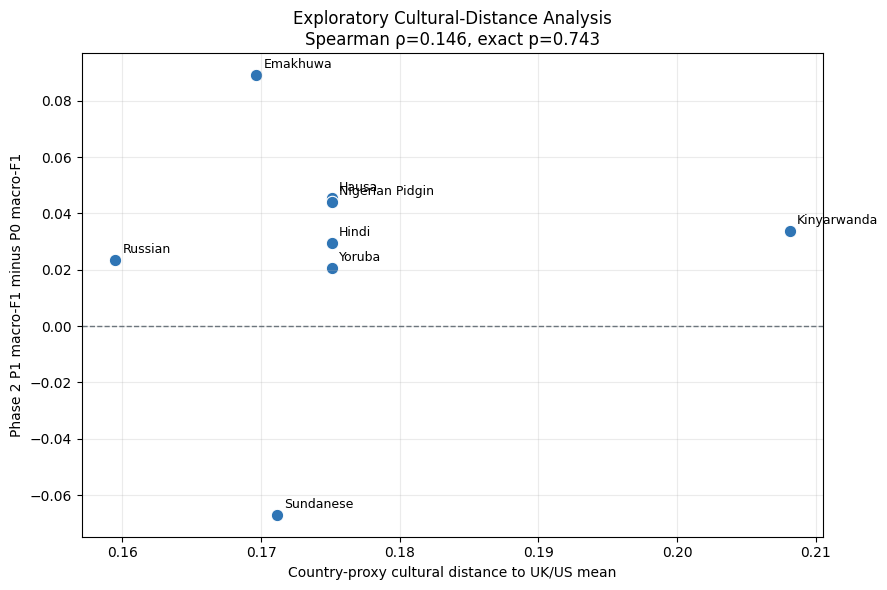

Saved: /content/drive/MyDrive/EmotionDetection/CAST_checkpoints/CulturalDistance/figures/cultural_distance_summary.png


In [ ]:
figure, axis = plt.subplots(figsize=(9, 6))
axis.axhline(0, color="#6c757d", linewidth=1, linestyle="--")
axis.scatter(
    primary["distance_anglophone_mean"],
    primary["p1_minus_p0"],
    s=80,
    color="#2F75B5",
    edgecolor="white",
    linewidth=0.8,
)

for row in primary.itertuples(index=False):
    axis.annotate(
        row.language,
        (row.distance_anglophone_mean, row.p1_minus_p0),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9,
    )

axis.set_xlabel("Country-proxy cultural distance to UK/US mean")
axis.set_ylabel("Phase 2 P1 macro-F1 minus P0 macro-F1")
axis.set_title(
    "Exploratory Cultural-Distance Analysis\n"
    f"Spearman ρ={primary_result['spearman_rho']:.3f}, "
    f"exact p={primary_result['exact_permutation_p_two_sided']:.3f}"
)
axis.grid(alpha=0.25)
figure.tight_layout()

figure_path = FIGURES_DIR / "cultural_distance_summary.png"
figure.savefig(figure_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {figure_path}")


## 7. Validate the complete output set


In [ ]:
expected_outputs = [
    RESULTS_DIR / "cultural_distance_language_analysis.csv",
    RESULTS_DIR / "cultural_distance_country_sensitivity.csv",
    RESULTS_DIR / "cultural_distance_test_summary.csv",
    RESULTS_DIR / "cultural_distance_leave_one_country_out.csv",
    RESULTS_DIR / "cultural_distance_conclusion.json",
    RESULTS_DIR / "cultural_distance_exploratory.xlsx",
    FIGURES_DIR / "cultural_distance_summary.png",
]
missing_outputs = [
    path for path in expected_outputs
    if not path.exists()
]
if missing_outputs:
    raise FileNotFoundError(
        "Expected outputs missing:\n"
        + "\n".join(f"  - {path}" for path in missing_outputs)
    )

assert len(language_analysis) == 9
assert len(primary) == 8
assert len(country_analysis) == 6
assert len(test_summary) == 5

print("Cultural-distance outputs verified.")
for path in expected_outputs:
    print("  ", path)


Cultural-distance outputs verified.
   /content/drive/MyDrive/EmotionDetection/CAST_checkpoints/CulturalDistance/results/cultural_distance_language_analysis.csv
   /content/drive/MyDrive/EmotionDetection/CAST_checkpoints/CulturalDistance/results/cultural_distance_country_sensitivity.csv
   /content/drive/MyDrive/EmotionDetection/CAST_checkpoints/CulturalDistance/results/cultural_distance_test_summary.csv
   /content/drive/MyDrive/EmotionDetection/CAST_checkpoints/CulturalDistance/results/cultural_distance_leave_one_country_out.csv
   /content/drive/MyDrive/EmotionDetection/CAST_checkpoints/CulturalDistance/results/cultural_distance_conclusion.json
   /content/drive/MyDrive/EmotionDetection/CAST_checkpoints/CulturalDistance/results/cultural_distance_exploratory.xlsx
   /content/drive/MyDrive/EmotionDetection/CAST_checkpoints/CulturalDistance/figures/cultural_distance_summary.png
